In [91]:
# Import libraries
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf          # <-- add: formula API
from itertools import combinations              # <-- add: for pairwise interactions

from sklearn import linear_model
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import PolynomialFeatures, MinMaxScaler
from statsmodels.stats.outliers_influence import OLSInfluence

%matplotlib inline
np.random.seed(42)              

**For 1(a), data was given already. Ans to Q 1(b((i) begins here**

In [92]:
ccpp = pd.read_excel('Folds5x2_pp.xlsx', sheet_name=0)
ccpp = ccpp.rename(columns={'AT': 'T', 'PE': 'EP'})
display(ccpp)
print(ccpp.shape)

,T,V,AP,RH,EP
0,14.96,41.76,1024.07,73.17,463.26
1,25.18,62.96,1020.04,59.08,444.37
2,5.11,39.40,1012.16,92.14,488.56
3,20.86,57.32,1010.24,76.64,446.48
4,10.82,37.50,1009.23,96.62,473.90
...,...,...,...,...,...
9563,16.65,49.69,1014.01,91.00,460.03
9564,13.19,39.18,1023.67,66.78,469.62
9565,31.32,74.33,1012.92,36.48,429.57
9566,24.48,69.45,1013.86,62.39,435.74


(9568, 5)


Rows: 9568
Column: 5

The first four columns are variables T (temperature), AP (ambient pressure), RH (relative humidity), and V (Exhaust Vacuum). The final column is output (PE).

**Ans to Q 1(b)(ii) starts here**

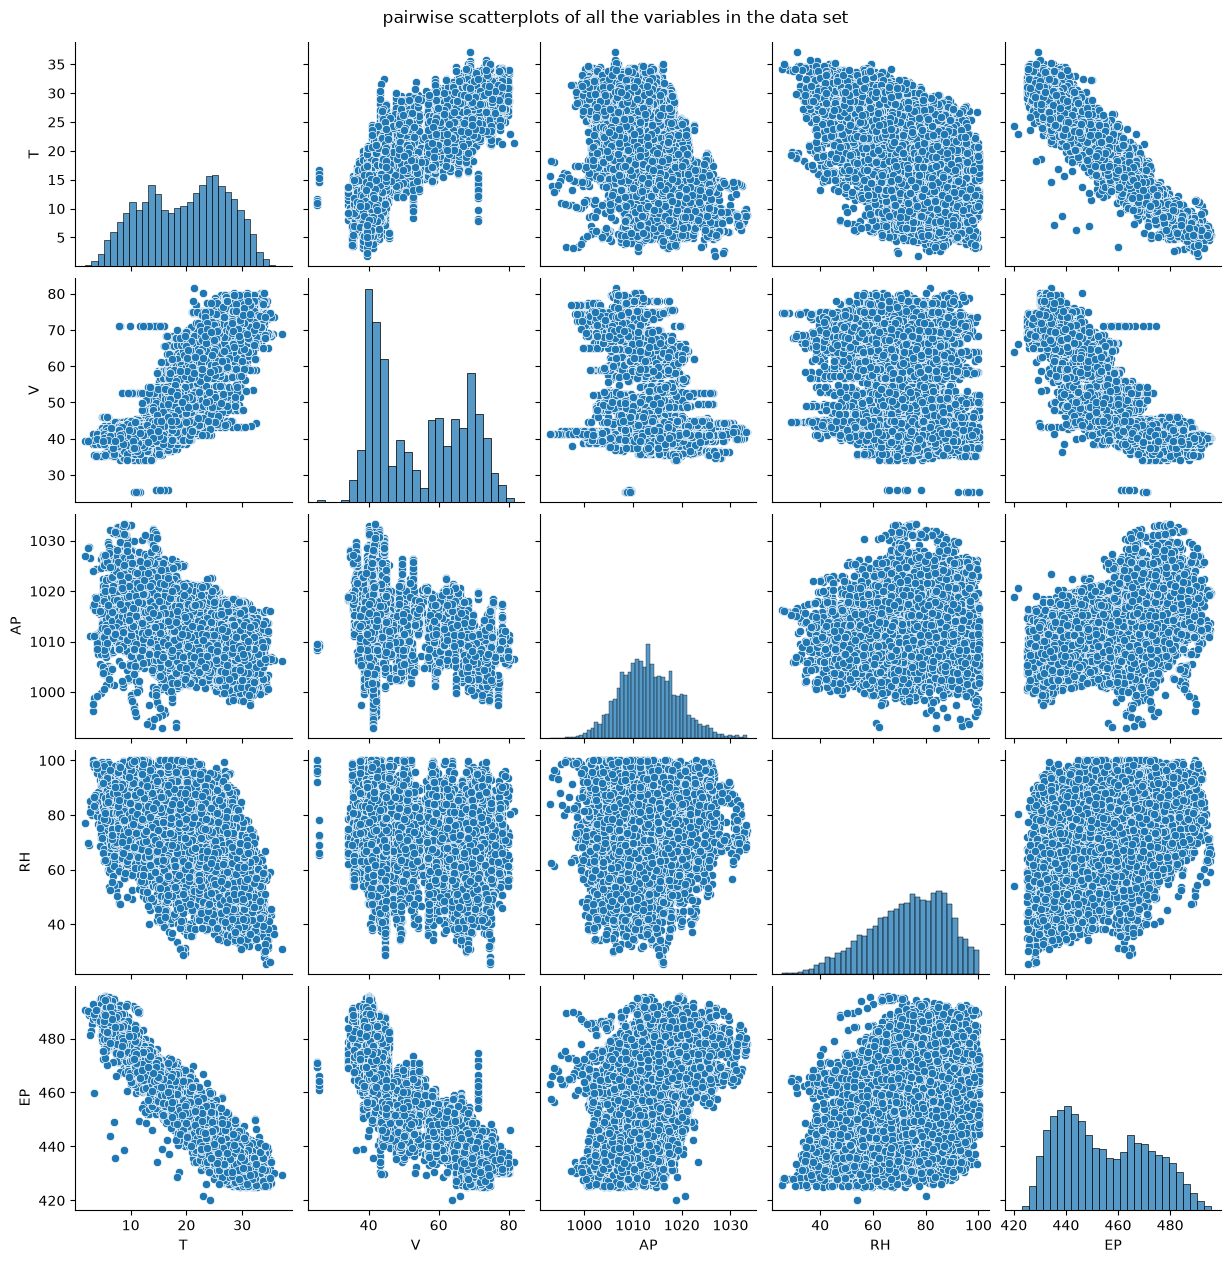

In [93]:
sns.pairplot(ccpp, diag_kind='auto')
plt.suptitle('pairwise scatterplots of all the variables in the data set', y=1.01)
plt.show()

T and V has inverse relationship with PE. However, the data is quite scattered so far. Ap and RH show no discernible trend yet.

**Ans to 1(b)(iii) starts here**

In [94]:
# calculate key
ccpp.describe()

,T,V,AP,RH,EP
count,9568.000000,9568.000000,9568.000000,9568.000000,9568.000000
mean,19.651231,54.305804,1013.259078,73.308978,454.365009
std,7.452473,12.707893,5.938784,14.600269,17.066995
min,1.810000,25.360000,992.890000,25.560000,420.260000
25%,13.510000,41.740000,1009.100000,63.327500,439.750000
50%,20.345000,52.080000,1012.940000,74.975000,451.550000
75%,25.720000,66.540000,1017.260000,84.830000,468.430000
max,37.110000,81.560000,1033.300000,100.160000,495.760000


**Answer to 1(C) begins here**

In [95]:
predictors = ['T', 'AP', 'RH', 'V']
simple_models = {}          # to hold each fitted model, keyed by predictor name

for p in predictors:
    X = sm.add_constant(ccpp[p])
    model = sm.OLS(ccpp['EP'], X).fit() #linear regression function call
    simple_models[p] = model      # will use later
    print(f"EP ~ {p}:  slope={model.params[p]:.4f},  "
          f"p-value={model.pvalues[p]:.3e},  R²={model.rsquared:.4f}")

EP ~ T:  slope=-2.1713,  p-value=0.000e+00,  R²=0.8989
EP ~ AP:  slope=1.4899,  p-value=0.000e+00,  R²=0.2688
EP ~ RH:  slope=0.4557,  p-value=0.000e+00,  R²=0.1519
EP ~ V:  slope=-1.1681,  p-value=0.000e+00,  R²=0.7565


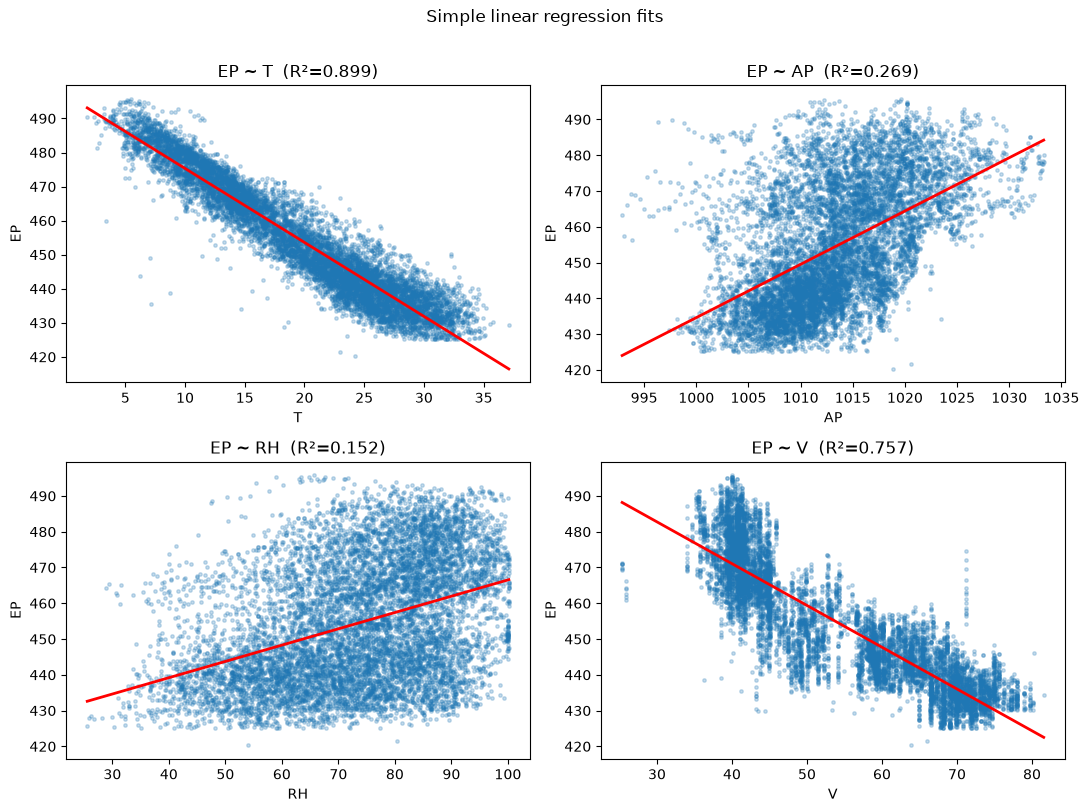

In [96]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))

for ax, p in zip(axes.ravel(), predictors):
    ax.scatter(ccpp[p], ccpp['EP'], s=6, alpha=0.25)      # the data
    # line drawing:
    xs = np.linspace(ccpp[p].min(), ccpp[p].max(), 100)   # 100 x-points across the range
    b0 = simple_models[p].params['const']                 # intercept
    b1 = simple_models[p].params[p]                        # slope
    ax.plot(xs, b0 + b1*xs, 'r-', lw=2)                    # y = b0 + b1*x
    ax.set(xlabel=p, ylabel='EP',
           title=f'EP ~ {p}  (R²={simple_models[p].rsquared:.3f})')

fig.suptitle('Simple linear regression fits', y=1.01)
fig.tight_layout()
plt.show()

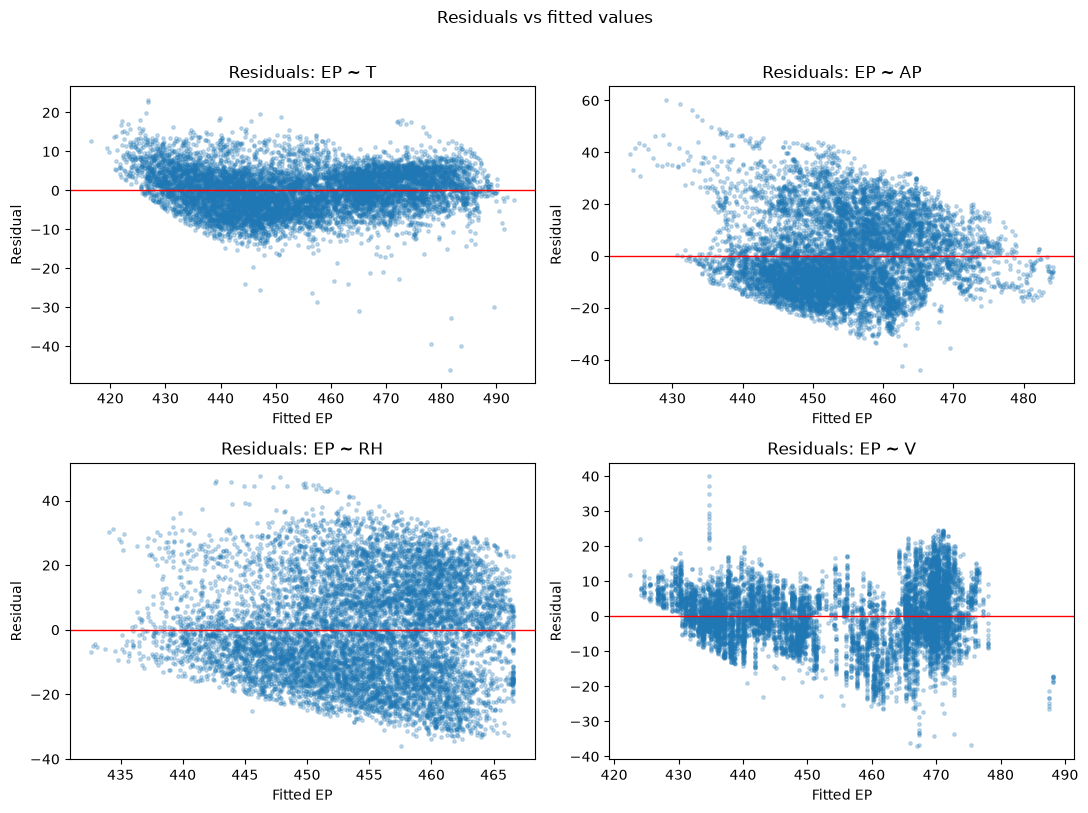

In [97]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))

for ax, p in zip(axes.ravel(), predictors):
    m = simple_models[p]
    ax.scatter(m.fittedvalues, m.resid, s=6, alpha=0.25)
    ax.axhline(0, color='r', lw=1)          # reference line at residual = 0
    ax.set(xlabel='Fitted EP', ylabel='Residual', title=f'Residuals: EP ~ {p}')

fig.suptitle('Residuals vs fitted values', y=1.01)
fig.tight_layout()
plt.show()

Using simple residual models, each model flags only a small number of points. I would not remove them yet as at this sample size they have negligible effect on the fitted slopes.

**Ans to 1(d) begins here**

In [98]:
X = sm.add_constant(ccpp[['T', 'AP', 'RH', 'V']])   # all predictors + intercept
multi_model = sm.OLS(ccpp['EP'], X).fit()
print(multi_model.summary())

                            OLS Regression Results                            
Dep. Variable:                     EP   R-squared:                       0.929
Model:                            OLS   Adj. R-squared:                  0.929
Method:                 Least Squares   F-statistic:                 3.114e+04
Date:                Sat, 26 Sep 2026   Prob (F-statistic):               0.00
Time:                        22:47:01   Log-Likelihood:                -28088.
No. Observations:                9568   AIC:                         5.619e+04
Df Residuals:                    9563   BIC:                         5.622e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        454.6093      9.749     46.634      0.0

p value is far from 0.05 for all four variables, and thus reject null hypothesis for all.

**Ans to 1e starts here**

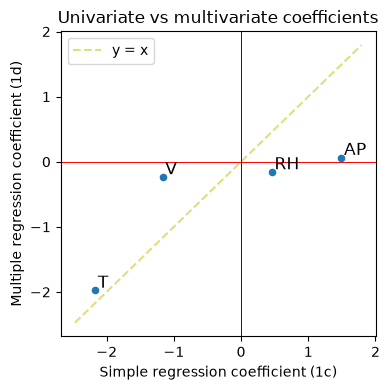

In [99]:
si_co = [simple_models[p].params[p] for p in predictors]
mu_co = [multi_model.params[p]      for p in predictors]

fig, ax = plt.subplots(figsize=(4, 4))
ax.scatter(si_co, mu_co, s=20, zorder=3)

# label each point with its predictor name
for x, y, p in zip(si_co, mu_co, predictors):
    ax.annotate(p, (x, y), textcoords='offset points', xytext=(2, 2), fontsize=12)

# reference lines
lims = [min(si_co + mu_co) - 0.3, max(si_co + mu_co) + 0.3]
ax.plot(lims, lims, 'y--', alpha=0.5, label='y = x')   # where coefs would be equal
ax.axhline(0, color='red', lw=0.7)
ax.axvline(0, color='blue', lw=0.7)

ax.set(xlabel='Simple regression coefficient (1c)',
       ylabel='Multiple regression coefficient (1d)',
       title='Univariate vs multivariate coefficients')
ax.legend()
fig.tight_layout()
plt.show()

Observations:
->For T, both models are similar.

-> For V, we see that its coefficient has higher estimated value in multiple regression than in univariate regression.

-> For AP, we see a large difference between the estimated coefficient value in univariate regression and multiple regression. 

-> For RH, in simple regression coefficient is positive (slightly), and in multivariate regression, the coefficient is negative. 

**Ans to 1(f) starts here**

In [100]:
poly_models = {}
for p in predictors:
    formula = f'EP ~ {p} + I({p}**2) + I({p}**3)'
    m = smf.ols(formula, data=ccpp).fit()
    poly_models[p] = m
    print(f"===== {formula} =====")
    print(m.summary().tables[1])       # coefficient table with p-values
    print()

===== EP ~ T + I(T**2) + I(T**3) =====
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    492.7281      0.673    732.248      0.000     491.409     494.047
T             -0.6103      0.124     -4.941      0.000      -0.852      -0.368
I(T ** 2)     -0.1251      0.007    -18.199      0.000      -0.139      -0.112
I(T ** 3)      0.0027      0.000     22.594      0.000       0.002       0.003

===== EP ~ AP + I(AP**2) + I(AP**3) =====
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.0747      0.009      8.415      0.000       0.057       0.092
AP            25.2556      3.001      8.415      0.000      19.372      31.139
I(AP ** 2)    -0.0500      0.006     -8.439      0.000      -0.062      -0.038
I(AP ** 3)  2.514e-05   2.92e-06      8.613      

In all cases, the coefficients x^3 terms have p<0.05 and in all cases except V, x^2 terms have p<0.05. Hence, yes, the data shows evidence of nonlinearity.

**Ans to 1(g) starts here**

In [101]:
interaction_model = smf.ols('EP ~ (T + AP + RH + V)**2', data=ccpp).fit()
print(interaction_model.summary())

                            OLS Regression Results                            
Dep. Variable:                     EP   R-squared:                       0.936
Model:                            OLS   Adj. R-squared:                  0.936
Method:                 Least Squares   F-statistic:                 1.405e+04
Date:                Sat, 26 Sep 2026   Prob (F-statistic):               0.00
Time:                        22:47:02   Log-Likelihood:                -27548.
No. Observations:                9568   AIC:                         5.512e+04
Df Residuals:                    9557   BIC:                         5.520e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    685.7825     78.640      8.721      0.0

Yes, there is evidence of interaction effect.

**Ans to 1h starts here**

In [102]:
train, test = train_test_split(ccpp, test_size=0.30, random_state=42)
print(f"train: {len(train)}, test: {len(test)}") 

train: 6697, test: 2871


In [103]:
def report_mse(model, name):
    train_mse = mean_squared_error(train['EP'], model.predict(train))
    test_mse  = mean_squared_error(test['EP'],  model.predict(test))
    print(f"{name}:  train MSE = {train_mse:.3f},  test MSE = {test_mse:.3f}")
    return train_mse, test_mse

In [104]:
modelA = smf.ols('EP ~ T + AP + RH + V', data=train).fit()
report_mse(modelA, "Model A (linear)")
full_formula = ('EP ~ (T + AP + RH + V)**2 '       
                '+ I(T**2) + I(AP**2) + I(RH**2) + I(V**2)')
modelB_full = smf.ols(full_formula, data=train).fit()
print(modelB_full.summary())

Model A (linear):  train MSE = 20.581,  test MSE = 21.240
                            OLS Regression Results                            
Dep. Variable:                     EP   R-squared:                       0.938
Model:                            OLS   Adj. R-squared:                  0.938
Method:                 Least Squares   F-statistic:                     7272.
Date:                Sat, 26 Sep 2026   Prob (F-statistic):               0.00
Time:                        22:47:02   Log-Likelihood:                -19160.
No. Observations:                6697   AIC:                         3.835e+04
Df Residuals:                    6682   BIC:                         3.845e+04
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------

>RH:V and V^2 should be dropped

In [105]:
better_formula = ('EP ~ T + AP + RH + V '
                  '+ I(T**2) + I(AP**2) + I(RH**2) '        
                  '+ T:AP + T:RH + T:V + AP:RH + AP:V')     
modelB = smf.ols(better_formula, data=train).fit()
report_mse(modelB, "Model B (better)")

Model B (better):  train MSE = 17.889,  test MSE = 18.652


(17.888579596899113, 18.65212626071)

**Ans to 1h starts here**

In [106]:
train, test = train_test_split(ccpp, test_size=0.30, random_state=42)
X_train_raw = train[['T', 'AP', 'RH', 'V']]
X_test_raw  = test[['T', 'AP', 'RH', 'V']]
y_train, y_test = train['EP'], test['EP']

In [107]:
scaler = MinMaxScaler().fit(X_train_raw)     
X_train_norm = scaler.transform(X_train_raw)
X_test_norm  = scaler.transform(X_test_raw)  

In [108]:
ks = range(1, 101)
results = {}

for tag, (Xtr, Xte) in {'raw':  (X_train_raw,  X_test_raw),
                        'norm': (X_train_norm, X_test_norm)}.items():
    train_errs, test_errs = [], []
    for k in ks:
        knn = KNeighborsRegressor(n_neighbors=k).fit(Xtr, y_train)
        train_errs.append(mean_squared_error(y_train, knn.predict(Xtr)))
        test_errs.append(mean_squared_error(y_test,  knn.predict(Xte)))
    results[tag] = (np.array(train_errs), np.array(test_errs))

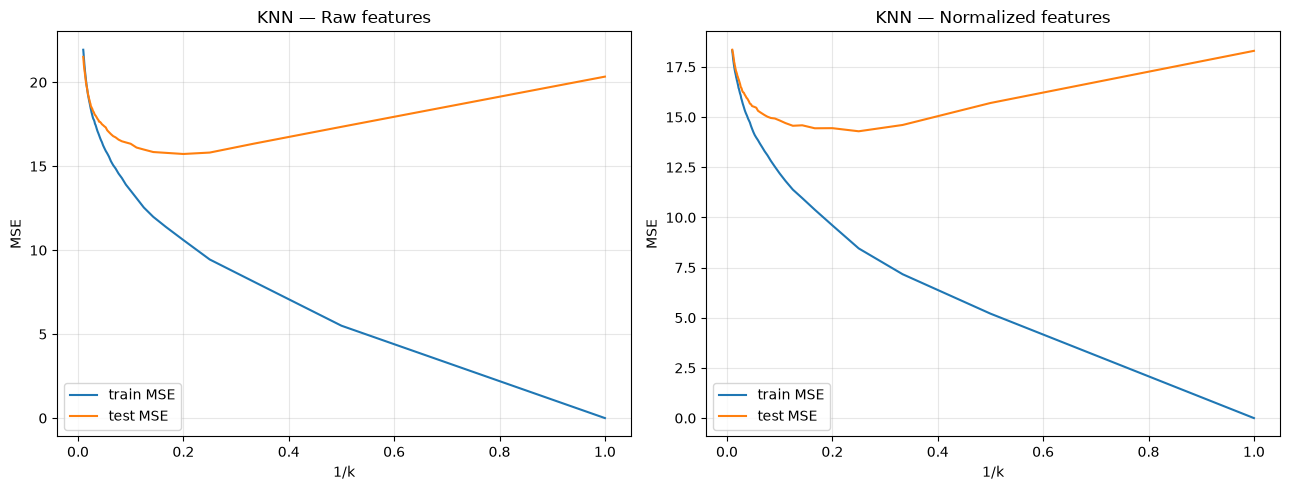

In [109]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
inv_k = [1/k for k in ks]

for ax, tag, title in [(axes[0], 'raw', 'Raw features'),
                       (axes[1], 'norm', 'Normalized features')]:
    tr, te = results[tag]
    ax.plot(inv_k, tr, label='train MSE', lw=1.5)
    ax.plot(inv_k, te, label='test MSE',  lw=1.5)
    ax.set(xlabel='1/k', ylabel='MSE', title=f'KNN — {title}')
    ax.legend(); ax.grid(alpha=0.3)

fig.tight_layout(); plt.show()

In [110]:
for tag in ['raw', 'norm']:
    te = results[tag][1]
    best_k = list(ks)[np.argmin(te)]
    print(f"{tag}: best k = {best_k}, test MSE = {te.min():.3f}")

raw: best k = 5, test MSE = 15.727
norm: best k = 4, test MSE = 14.291


**Answer to 1h starts here**

In [111]:
best_linear_mse = mean_squared_error(y_test, modelB.predict(test))   
best_knn_mse = results['norm'][1].min()                              
print(f"Best linear (Model B):        test MSE = {best_linear_mse:.3f}")
print(f"Best KNN (normalized, k=4):   test MSE = {best_knn_mse:.3f}")

Best linear (Model B):        test MSE = 18.652
Best KNN (normalized, k=4):   test MSE = 14.291


KNN regression with normalized features and k=4 gives the best results.

**Ans to 2 here**

(a) Better. More data= better fitting without overfitting.

(b) Worse. Too little data, too many predictors.

(c) Better. A flexible method can match the non-linear shape.

(d) Worse. A flexible method chases the noise and overfits.

**Ans to 3 here**

(a) Using standard Euclidean formula, the calculated Euclidean distances are:
d1=3  
d2=2  
d3=sqrt(10)  
d4=sqrt(5)  
d5=sqrt(2)  
d6=sqrt(3)  

(b) The nearest neighbour is green with d5=1.41.  

(c) The nearest neighbours are d2 (red), d5(green), and d6 (red). Red is majority, and red is the answer.  

(d) High K makes the fit linear. Since the data is linear, small K is better.


**References**
https://scikit-learn.org/stable/modules/preprocessing.html#generating-polynomial-features  
AI Usage:  
Finding functions such as smf.ols('EP ~ (T+AP+RH+V)**2 + I(T**2)', data=...), MinMaxScaler().fit() / .transform()  
Debugging errors in hard coded cells
Looking up syntax for useful functions